# Which Customers to Target

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime  import datetime

## Background

In the experiment simulated by the data, an advertising promotion was tested to see if it would bring more customers to purchase a specific product priced at $10. Since it costs the company $0.15 to send out each promotion, it would be best to limit that promotion only to those that are most receptive to the promotion.

### Task

- Analyze the results of the experiment and identify the effect of the Treatment on product purchase and Net Incremental Revenue;
- Build a model to select the best customers to target that maximizes the Incremental Response Rate and Net Incremental Revenue;
- Score the Test.csv using the model and select the best customers and share the customer ID’s as csv file;
- Explain briefly the approach used in a separate document and also share the code that can be executed to reproduce results.


In [48]:
train_df = pd.read_csv('/Users/rosiebai/Downloads/datasets-19/Training.csv')
test_df = pd.read_csv('/Users/rosiebai/Downloads/datasets-19/Test.csv')

In [49]:
train_df.head()

,ID,Promotion,purchase,V1,V2,V3,V4,V5,V6,V7
0,1,No,0,2,30.443518,-1.165083,1,1,3,2
1,3,No,0,3,32.159350,-0.645617,2,3,2,2
2,4,No,0,2,30.431659,0.133583,1,1,4,2
3,5,No,0,0,26.588914,-0.212728,2,1,4,2
4,8,Yes,0,3,28.044331,-0.385883,1,1,2,2


In [50]:
test_df.head()

,ID,Promotion,purchase,V1,V2,V3,V4,V5,V6,V7
0,2,No,0,1,41.376390,1.172517,1,1,2,2
1,6,Yes,0,1,25.163598,0.653050,2,2,2,2
2,7,Yes,0,1,26.553778,-1.597972,2,3,4,2
3,10,No,0,2,28.529691,-1.078506,2,3,2,2
4,12,No,0,2,32.378538,0.479895,2,2,1,2


In [51]:
train_df['purchase'].value_counts()

purchase
0    83494
1     1040
Name: count, dtype: int64

In [52]:
train_df.isna().sum()

ID           0
Promotion    0
purchase     0
V1           0
V2           0
V3           0
V4           0
V5           0
V6           0
V7           0
dtype: int64

Incremental Response Rate (IRR) = conversion rate (treatment) - conversion rate (control)
 = purchase rate (promotion) - purchase rate (not receiving promotion)

In [53]:
ct = pd.crosstab(train_df['Promotion'], train_df['purchase'])
ct

purchase,0,1
Promotion,,
No,41851,319
Yes,41643,721


In [54]:
def compute_irr(df, treatment_col, outcome_col, treatment_label, control_label):
    ct = pd.crosstab(df[treatment_col], df[outcome_col])
    
    rates = ct[1] / ct.sum(axis=1)
    
    return rates[treatment_label] - rates[control_label]

irr = compute_irr(train_df, 'Promotion', 'purchase', 'Yes', 'No')
irr_pp = irr * 100
irr_pp

0.9454547819772702

## NIR depicts how much is made (or lost) by sending out the promotion. 
- Net Incremental Revenue = (Incremental conversions × N_treated) − cost of treatment per user × N_treated


In [55]:
def compute_net_incremental_revenue(
    df,
    treatment_col,
    outcome_col,
    treatment_label,
    control_label,
    revenue_per_conversion,
    cost_per_treated_user=0,
):
    import pandas as pd
    
    # Crosstab
    ct = pd.crosstab(df[treatment_col], df[outcome_col])
    
    # Conversion rates
    rates = ct[1] / ct.sum(axis=1)
    
    cr_treatment = rates[treatment_label]
    cr_control = rates[control_label]
    
    # IRR
    irr = cr_treatment - cr_control
    
    # Number of treated users
    n_treatment = ct.loc[treatment_label].sum()
    
    # Incremental conversions
    incremental_conversions = irr * n_treatment
    
    # Incremental revenue
    incremental_revenue = incremental_conversions * revenue_per_conversion
    
    # Treatment cost
    total_cost = n_treatment * cost_per_treated_user
    
    # Net incremental revenue
    net_incremental_revenue = incremental_revenue - total_cost
    
    return {
        "irr": irr,
        "incremental_conversions": incremental_conversions,
        "incremental_revenue": incremental_revenue,
        "total_cost": total_cost,
        "net_incremental_revenue": net_incremental_revenue,
    }

In [56]:
result = compute_net_incremental_revenue(
    train_df,
    treatment_col='Promotion',
    outcome_col='purchase',
    treatment_label='Yes',
    control_label='No',
    revenue_per_conversion=10,      
    cost_per_treated_user=0.15       
)

result

{'irr': 0.009454547819772702,
 'incremental_conversions': 400.53246383685075,
 'incremental_revenue': 4005.3246383685073,
 'total_cost': 6354.599999999999,
 'net_incremental_revenue': -2349.275361631492}

In [57]:
train_df.Promotion.value_counts()

Promotion
Yes    42364
No     42170
Name: count, dtype: int64

## Two-Model Approach

In [58]:
from sklearn.ensemble import RandomForestClassifier

features = ['V1','V2','V3','V4','V5','V6','V7']

# Split treated and control
train_treat = train_df[train_df['Promotion'] == 'Yes']
train_ctrl = train_df[train_df['Promotion'] == 'No']

# Train models
model_t = RandomForestClassifier()
model_c = RandomForestClassifier()

model_t.fit(train_treat[features], train_treat['purchase'])
model_c.fit(train_ctrl[features], train_ctrl['purchase'])

RandomForestClassifier()

In [59]:
# Predict probabilities
p_t = model_t.predict_proba(test_df[features])[:,1]
p_c = model_c.predict_proba(test_df[features])[:,1] # Give me the probability that purchase = 1 for every row

# Uplift (individual treatment effect)
test_df['uplift'] = p_t - p_c

In [60]:
R = 10      # revenue per conversion
C = 0.15    # cost per promotion

test_df['incremental_revenue'] = test_df['uplift'] * R - C

In [61]:
# Select users with positive expected value
targeted = test_df[test_df['incremental_revenue'] > 0]

In [62]:
test_df = test_df.sort_values(by='uplift', ascending=False).reset_index(drop=True)

# cumulative NIR curve
test_df['cum_nir'] = (test_df['uplift'] * R - C).cumsum()

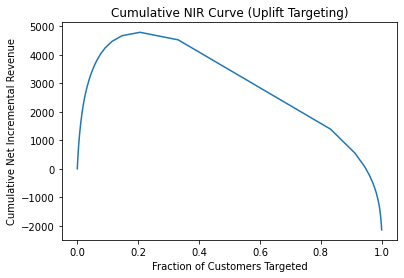

In [63]:
# % of population targeted
test_df['pct_targeted'] = np.arange(1, len(test_df)+1) / len(test_df)

# Plot
plt.figure()
plt.plot(test_df['pct_targeted'].to_numpy(), test_df['cum_nir'].to_numpy())
plt.xlabel('Fraction of Customers Targeted')
plt.ylabel('Cumulative Net Incremental Revenue')
plt.title('Cumulative NIR Curve (Uplift Targeting)')
plt.show()

In [64]:
optimal_idx = test_df['cum_nir'].idxmax()

optimal_fraction = test_df.loc[optimal_idx, 'pct_targeted']
n_target = optimal_idx + 1  # because index starts at 0

optimal_fraction, n_target

(0.20523409363745498, 8548)

Target the top 20% of customers ranked by uplift to maximize NIR.

In [65]:
best_customers = test_df.head(n_target)

In [66]:
best_customers[['ID']].to_csv('selected_customers.csv', index=False)